# New section

In [ ]:
# Step 1: Install required libraries
!pip install shap streamlit pyngrok scikit-learn xgboost --quiet

      TV  radio  newspaper  sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9


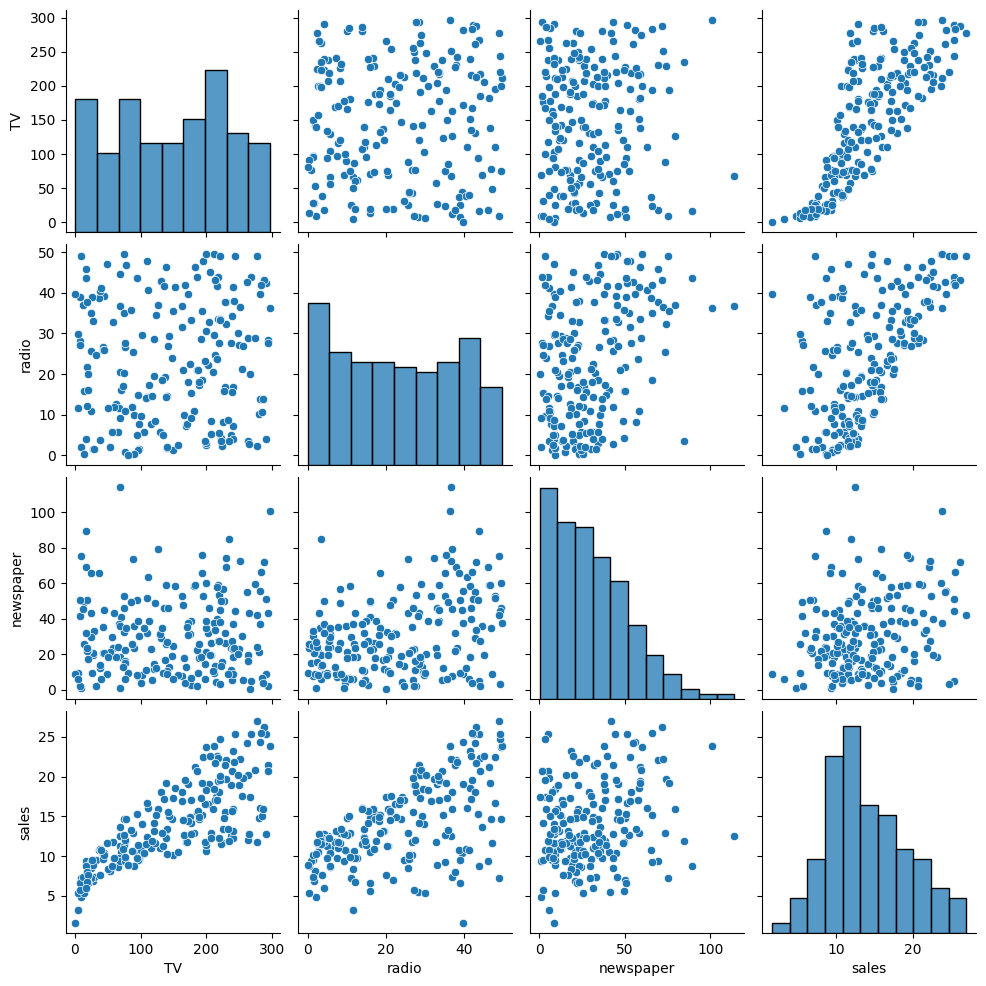

R² Score: 0.9760312992910549


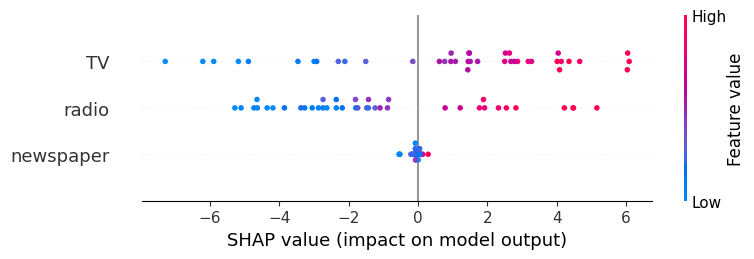

Optimal Budget Allocation:
TV: $30.00, Radio: $30.00, Newspaper: $40.00


In [ ]:
# MARKETING MIX MODELING PROJECT - COLAB NOTEBOOK



import pandas as pd
from io import StringIO
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

import shap

# Read CSV
df = pd.read_csv("/content/advertising (1).csv")
print(df.head())

# Step 3: EDA
sns.pairplot(df)
plt.show()

# Step 4: Train-Test Split
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Step 5: Train ML Model
model = XGBRegressor()
model.fit(X_train, y_train)

# Step 6: Evaluate Model
preds = model.predict(X_test)
print("R² Score:", r2_score(y_test, preds))

# Step 7: Explain with SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

# Step 8: Optimization
from scipy.optimize import minimize

def objective(x):
    pred = model.predict([x])
    return -pred[0]  # Maximize sales

budget = 100
constraints = ({'type': 'eq', 'fun': lambda x: sum(x) - budget})
bounds = [(0, budget)] * 3
result = minimize(objective, x0=[30, 30, 40], bounds=bounds, constraints=constraints)

print("Optimal Budget Allocation:")
print(f"TV: ${result.x[0]:.2f}, Radio: ${result.x[1]:.2f}, Newspaper: ${result.x[2]:.2f}")

In [ ]:
# --- STEP 8: Save the Model ---
joblib.dump(model, "marketing_model.pkl")
print("Model saved as marketing_model.pkl")

# --- STEP 9: Download the Model File ---
from google.colab import files
files.download("marketing_model.pkl")

Model saved as marketing_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# zomato


                    week  zomato_orders    revenue  facebook_spend  \
0  2022-01-03/2022-01-09            131  113971.01           63.62   
1  2022-01-10/2022-01-16             94   74249.67           52.99   
2  2022-01-17/2022-01-23            151  108581.39           67.83   
3  2022-01-24/2022-01-30            140  108382.91           73.18   
4  2022-01-31/2022-02-06            100   83376.83           53.13   

   google_spend  influencer_spend  tv_spend  promo_discount_percent  
0         57.50             27.75     47.13                   18.45  
1         41.37             31.81     32.40                   12.99  
2         50.83             33.98     54.25                   16.12  
3         49.06             37.57     50.19                   15.06  
4         36.76             32.37     37.00                   15.49  


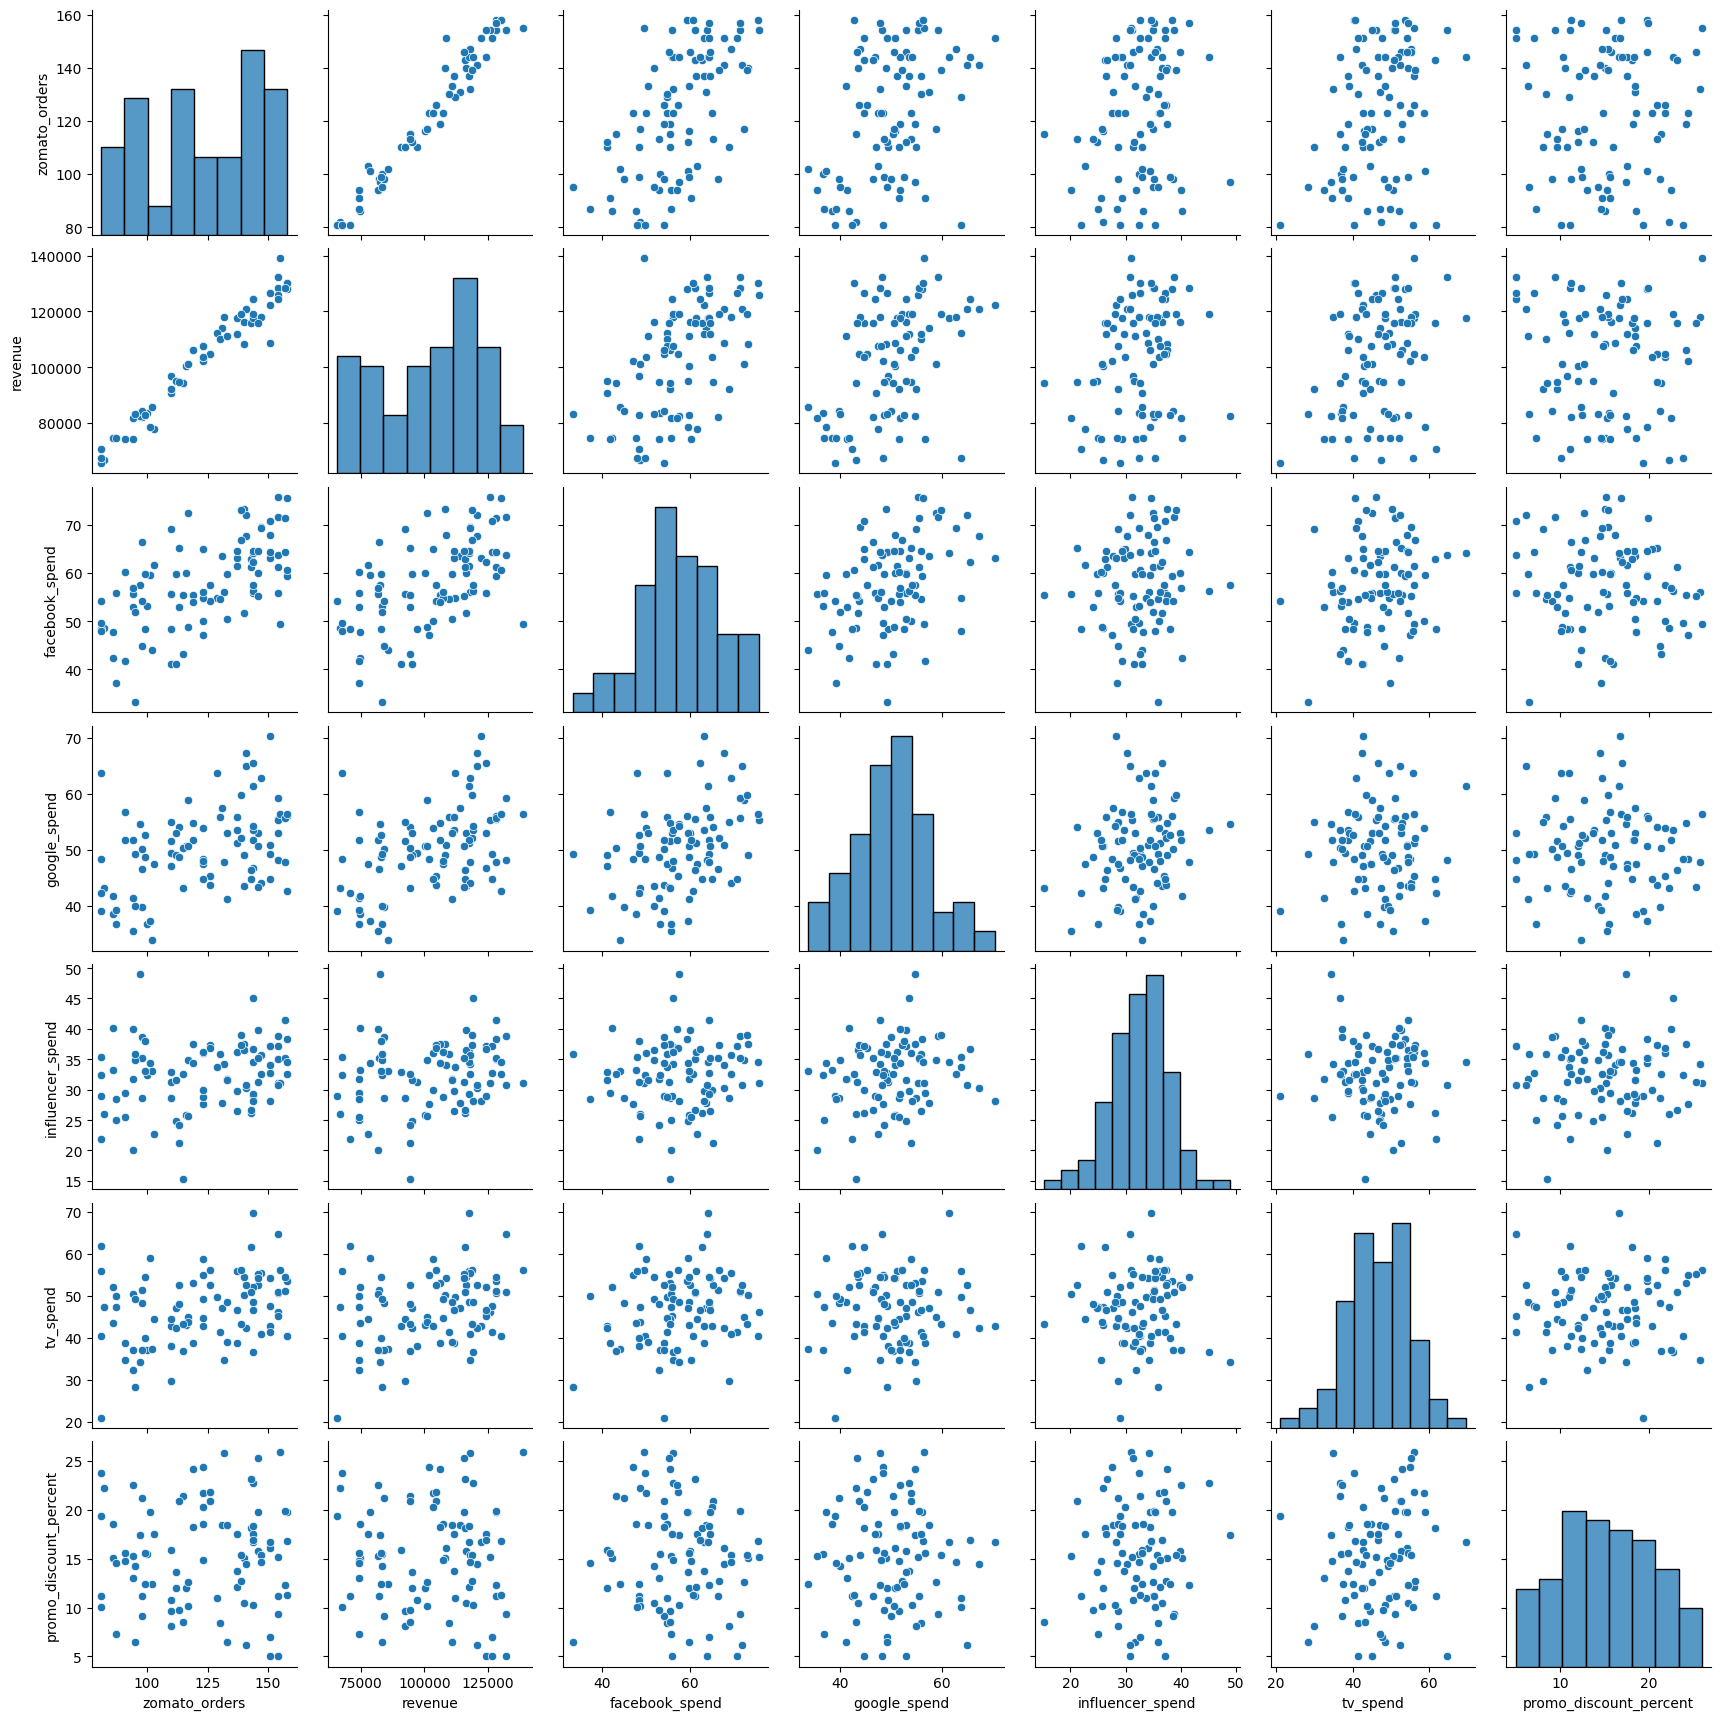

R² Score: 0.238348126411438


/tmp/ipython-input-7-311628036.py:39: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=X.columns)


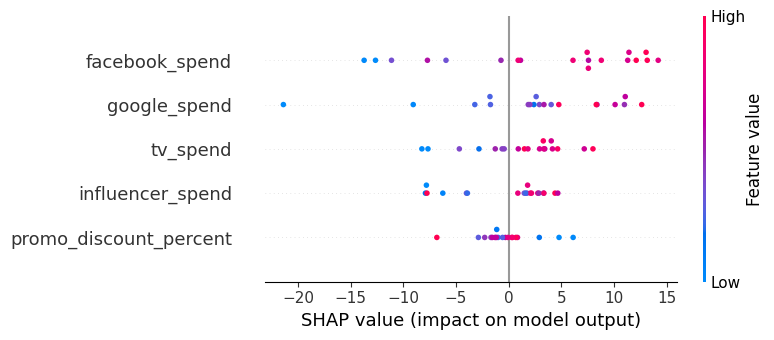


Optimal Budget Allocation:
facebook_spend: ₹25.00
google_spend: ₹25.00
influencer_spend: ₹25.00
tv_spend: ₹25.00
promo_discount_percent: %15.00


In [ ]:
# Zomato MMM Project: Without Lag Features

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scipy.optimize import minimize
import shap

# Load dataset
df = pd.read_csv("/content/zomato_mmm_realistic.csv")  # <-- Change path if needed
print(df.head())

# Exploratory Data Analysis
sns.pairplot(df.drop(columns=['week']))
plt.show()

# Define features and target
X = df[['facebook_spend', 'google_spend', 'influencer_spend', 'tv_spend', 'promo_discount_percent']]
y = df['zomato_orders']

# Train-test split (no shuffle for time-aware modeling)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train model
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

# Evaluate model
preds = model.predict(X_test)
print("R² Score:", r2_score(y_test, preds))

# SHAP explainability
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X.columns)

# Optimization step
def objective(x):
    return -model.predict([x])[0]  # Maximize orders (minimize -orders)

budget = 100  # Total marketing budget (in thousands)
bounds = [(0, budget)] * 4 + [(0, 50)]  # Promo % has max bound of 50%
constraints = [{'type': 'eq', 'fun': lambda x: sum(x[:4]) - budget}]  # Total spend = budget

# Initial guess (equal allocation + 15% promo)
x0 = [25, 25, 25, 25, 15]

result = minimize(objective, x0=x0, bounds=bounds, constraints=constraints)

# Display results
print("\nOptimal Budget Allocation:")
channels = ['facebook_spend', 'google_spend', 'influencer_spend', 'tv_spend', 'promo_discount_percent']
for name, val in zip(channels, result.x):
    unit = "%" if "percent" in name else "₹"
    print(f"{name}: {unit}{val:.2f}")


In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(model, X, y, cv=5, scoring='r2')


array([ 0.34456694, -0.66466057,  0.09956115, -0.30175328,  0.34892678])

In [ ]:
import pandas as pd
import numpy as np

# Load your weekly_df (or replace with your base DataFrame)
df = pd.read_csv("/content/larger_mmm_dataset.csv")  # Or use weekly_df if already in memory

# Inject realistic correlation + noise into marketing spends
np.random.seed(42)
df['facebook_spend'] = np.random.normal(40, 8, len(df)) + 0.15 * df['zomato_orders']
df['google_spend'] = np.random.normal(35, 7, len(df)) + 0.12 * df['zomato_orders']
df['influencer_spend'] = np.random.normal(20, 5, len(df)) + 0.10 * df['zomato_orders']
df['tv_spend'] = np.random.normal(30, 10, len(df)) + 0.13 * df['zomato_orders']
df['promo_discount_percent'] = np.random.normal(15, 5, len(df)).clip(5, 40)

# Clip, round
for col in ['facebook_spend', 'google_spend', 'influencer_spend', 'tv_spend']:
    df[col] = df[col].clip(lower=5).round(2)
df['promo_discount_percent'] = df['promo_discount_percent'].round(2)

# Save the updated DataFrame
df.to_csv("zomato_mmm_realistic.csv", index=False)


In [ ]:
# --- STEP 8: Save the Model ---
import joblib

joblib.dump(model, "marketing_model.pkl")
print("Model saved as marketing_model.pkl")

# --- STEP 9: Download the Model File ---
from google.colab import files
files.download("marketing_model.pkl")

Model saved as marketing_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>